In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import lime
import lime.lime_tabular

import matplotlib.pyplot as plt
import plotly.express as px

import huggingface_hub
from transformers import Wav2Vec2Model
import os
from dotenv import load_dotenv
import random
from tqdm import tqdm
import glob
from torch.utils.data import Dataset, DataLoader, random_split
from collections import OrderedDict
import soundfile as sf
import librosa


# from transformers import Wav2Vec2Model

from scipy.optimize import brentq
from scipy.interpolate import interp1d

from huggingface_hub import hf_hub_download

c:\Users\eglha\anaconda3\envs\torch_gen\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# load in huggingface authorization token
load_dotenv()
hf_auth=os.getenv("hf_auth")

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
class Wav2Vec2Deepfake(nn.Module):

    def __init__(self):
        super().__init__()
        self.wav2vec = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base"
        )
        hidden_size = (
            self.wav2vec.config.hidden_size
        )
        for param in self.wav2vec.parameters():

            param.requires_grad = False
        for layer in self.wav2vec.encoder.layers[-2:]:

            for param in layer.parameters():

                param.requires_grad = True

        self.classifier = nn.Sequential(

            nn.Linear(hidden_size, 256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256, 2)
        )

    def forward(self, x):

        outputs = self.wav2vec(
            x
        )

        hidden_states = (
            outputs.last_hidden_state
        )

        pooled = hidden_states.mean(
            dim=1
        )

        logits = self.classifier(
            pooled
        )

        return logits

In [6]:
# import Wav2Vec Model from HuggingFace

w2v_model=Wav2Vec2Deepfake()
wav2vec_name='best_model.pth'
w2v_checkpoint=hf_hub_download(
    repo_id='rde6mn/no_aug_w2v_4s',
    filename=wav2vec_name
)
w2v_checkpoint=torch.load(w2v_checkpoint, map_location=device)
state_dict=w2v_checkpoint["model_state_dict"]

w2v_model.load_state_dict(state_dict)
w2v_model.eval()

# w2v parameters
SR = 16000
MAX_LEN = 4 * SR
BATCH_SIZE = 16
EPOCHS = 5
LR = 1e-5
NUM_WORKERS = 4

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 42209.10it/s]
[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
print(w2v_model)

Wav2Vec2Deepfake(
  (wav2vec): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True, bias=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=Fal

In [8]:
audiofile_dir=r"H:\My Drive\ASVSpoof_Data\unzipped2019\LA\LA\ASVspoof2019_LA_eval\flac"
audiofiles=glob.glob(os.path.join(audiofile_dir, "*.flac"))

def process_audio(audio_path):
    try:
        waveform, sr = sf.read(audio_path)
        if len(waveform.shape) > 1:
            waveform = waveform.mean(axis=1)

        if sr != SR:
            waveform = librosa.resample(
                waveform,
                orig_sr=sr,
                target_sr=SR
            )
    except Exception as e:
        try:
            waveform, sr = librosa.load(
                audio_path,
                sr=SR,
                mono=True
            )
        except Exception as e2:
            print(f"FAILED TO LOAD: {audio_path}")
            return None
    if len(waveform) > MAX_LEN:
        waveform = waveform[:MAX_LEN]
    else:
        waveform = np.pad(
            waveform,
            (0, MAX_LEN - len(waveform))
        )
    waveform = torch.tensor(
        waveform
    ).float()

    return waveform

In [9]:
print(audiofiles[:5])

['H:\\My Drive\\ASVSpoof_Data\\unzipped2019\\LA\\LA\\ASVspoof2019_LA_eval\\flac\\LA_E_9271719.flac', 'H:\\My Drive\\ASVSpoof_Data\\unzipped2019\\LA\\LA\\ASVspoof2019_LA_eval\\flac\\LA_E_9271805.flac', 'H:\\My Drive\\ASVSpoof_Data\\unzipped2019\\LA\\LA\\ASVspoof2019_LA_eval\\flac\\LA_E_9271855.flac', 'H:\\My Drive\\ASVSpoof_Data\\unzipped2019\\LA\\LA\\ASVspoof2019_LA_eval\\flac\\LA_E_9271901.flac', 'H:\\My Drive\\ASVSpoof_Data\\unzipped2019\\LA\\LA\\ASVspoof2019_LA_eval\\flac\\LA_E_9272037.flac']


In [10]:
waveforms=[]

# Preprocess the waveforms
for file in audiofiles:
    audio_path=file
    waveform=process_audio(audio_path)
    if waveform is not None:
        waveforms.append(waveform)
        if len(waveforms)==100:
                break
    else:
        print(f"FAILED TO LOAD: {audio_path}")
    


In [11]:
len(waveforms)

100

In [12]:
def generate_output(waveform):
    with torch.no_grad():

        waveform = waveform.unsqueeze(0)
        outputs = w2v_model(waveform)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = (probs >= 0.5).long()

    return probs, preds



In [13]:
paths=audiofiles[:100]
filenames=[]
for path in paths:
    filename=os.path.basename(path)
    filenames.append(filename)

In [14]:
protocol=pd.read_csv(r"H:\My Drive\ASVSpoof_Data\unzipped2019\LA\LA\ASVspoof2019_LA_cm_protocols\ASVspoof2019.LA.cm.eval.trl.txt", header=None, sep=' ')
# protocol=protocol.rename(columns={0: 'LA_ID', 1: 'LA_E_NUM', 3: 'Source', 4: 'Label'}, inplace=True)
protocol.sample(5)

,0,1,2,3,4
9929,LA_0064,LA_E_9265511,-,-,bonafide
63131,LA_0013,LA_E_1925274,-,A11,spoof
48136,LA_0014,LA_E_1925859,-,A15,spoof
45203,LA_0008,LA_E_9320267,-,A16,spoof
8630,LA_0010,LA_E_1505099,-,A15,spoof


In [16]:
wav0_output=generate_output(waveforms[25])
wav0_output


(tensor([0.0017]), tensor([0]))

In [17]:
def make_spectrogram(waveform, sr=SR):
    # Compute the spectrogram
    S = librosa.stft(waveform.numpy())
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    # Plot the spectrogram
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram')
    plt.tight_layout()
    plt.show()

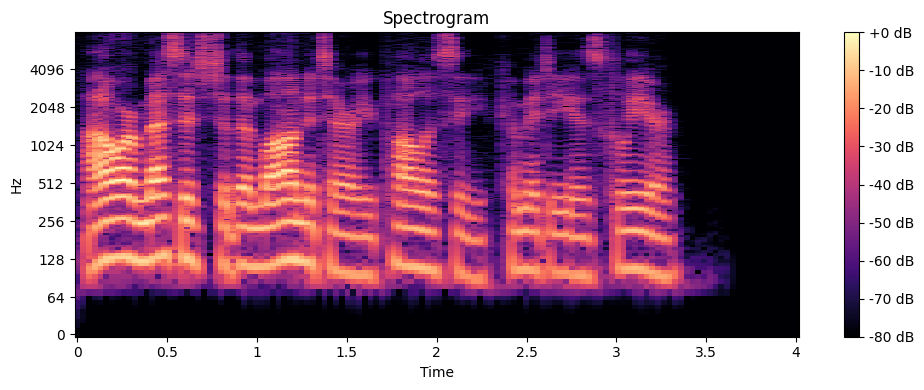

In [18]:
make_spectrogram(waveforms[20])

In [41]:
def predict_fn(waveform):
    with torch.no_grad():
        if isinstance(waveform, np.ndarray):
            waveform = torch.from_numpy(waveform).float()
        if waveform.dim() == 1:
            waveform=waveform.unsqueeze(0)

        outputs = w2v_model(waveform)
        probs = torch.softmax(outputs, dim=1)
        preds = (probs >= 0.5).long()
        return probs.numpy()


def get_lime(waveform, idx):
    # run the prediction on the waveform
    probs= predict_fn(waveform)
    pred = int(probs[0].argmax())
    prob = float(probs[0, pred])

    file_name=str(audiofiles[idx]).replace(f"H:\\My Drive\\ASVSpoof_Data\\unzipped2019\\LA\\LA\\ASVspoof2019_LA_eval\\flac\\", "").replace(".flac", "")
    print(f"File Name: {file_name}")
    protocol_row=protocol[protocol[1] == file_name]
    label=protocol_row[4].values[0]
    label_num=1 if label=="spoof" else 0

    # Return the LIME values and the predicted label
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=np.array(waveforms),
        mode='classification',
        class_names=[1, 0],
        feature_names=[f'Feature {i}' for i in range(len(waveform))],
        discretize_continuous=True
    )
    print("Built LIME Explainer")

    explanation=lime_explainer.explain_instance(
        data_row=waveform.numpy(),
        predict_fn=predict_fn,
        num_features=8,
        num_samples=1
    )
    print("Generated LIME Explanation")
    # Create Text Labels for the predicted and true labels

    print(f"Predicted Label: {pred}, True Label: {label_num}({label})")
    print(f"Predicted Probability: {prob:.4f}")
    print("LIME Explanation: (feature constributions):")
    for feature, weight in explanation.as_list():
        print(f"  {feature}: {weight:.4f}")

    # Visualize the Spectrogram

    make_spectrogram(waveform)
    

## The issue with with this part of the code in the above block 

    explanation=lime_explainer.explain_instance(
        data_row=waveform.numpy(),
        predict_fn=predict_fn,
        num_features=8,
        num_samples=1
    )

it converts waveform to a numpy array and then tries to run the predict_fn on it but that takes a tensor as input

File Name: LA_E_9274207
Built LIME Explainer
Generated LIME Explanation
Predicted Label: 0, True Label: 1(spoof)
Predicted Probability: 0.9983
LIME Explanation: (feature constributions):
  Feature 0 > 0.00: 0.0000
  Feature 1 > 0.00: 0.0000
  Feature 2 > 0.00: 0.0000
  Feature 3 > 0.00: 0.0000
  Feature 4 <= -0.00: 0.0000
  Feature 5 > 0.00: 0.0000
  Feature 6 > 0.00: 0.0000
  Feature 7 > 0.00: 0.0000


c:\Users\eglha\anaconda3\envs\torch_gen\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


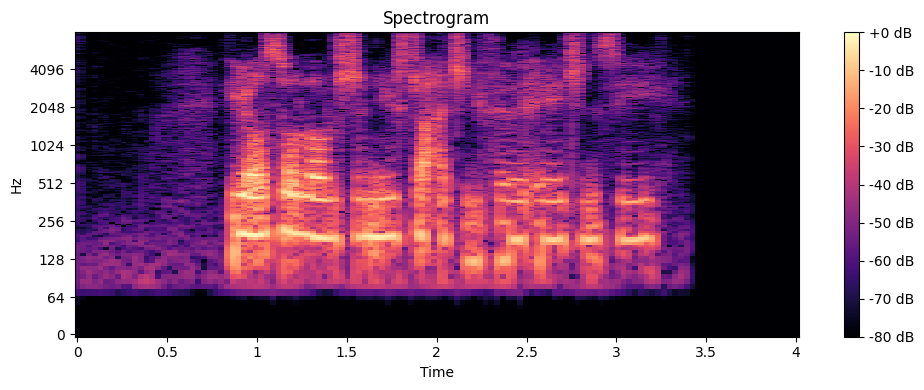

In [42]:
get_lime(waveforms[25], 25)